# Problem Statement

**Linear regression by using Deep Neural network**: Implement Boston housing price prediction problem by Linear regression using Deep Neural network. Use Boston House price prediction dataset. 

# Import Library

In [1]:
# Data analysis and visualization
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline 

# Preprocessing and evaluation
from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_transformer#🔹 Imports make_column_transformer which allows you to apply different transformations to different columns of your dataset (e.g., scaling numerical columns while encoding categorical ones).
from sklearn.preprocessing import MinMaxScaler

# Load Data

This line loads the Boston Housing dataset using TensorFlow's Keras API and splits it into training and testing sets. The dataset contains information about housing in Boston suburbs, such as crime rate, average number of rooms per dwelling, and other factors, with the goal of predicting the median house value. The load_data function returns two tuples: one for training data and one for testing data. Each tuple contains the input features (X) and the corresponding target values (y), which are the house prices. The path argument specifies the filename (boston_housing_npz) to save or load the data locally; if the file doesn’t exist, TensorFlow will download it automatically. The test_split parameter indicates that 20% of the data should be reserved for testing, while the remaining 80% is used for training. The seed value ensures that the split between training and testing is consistent every time the code runs, enabling reproducible results.

In [2]:
(X_train , y_train), (X_test , y_test) = tf.keras.datasets.boston_housing.load_data(
                                            path = 'boston_housing_npz',
                                            test_split = 0.2,
                                            seed = 42
                                        )

# Exploratory Data Analysis

## Initial Observation

In [3]:
# Checking the data shape and type
(X_train.shape, type(X_train)), (X_test.shape, type(X_test)), (y_train.shape, type(y_train)), (y_test.shape, type(y_test)),

(((404, 13), numpy.ndarray),
 ((102, 13), numpy.ndarray),
 ((404,), numpy.ndarray),
 ((102,), numpy.ndarray))

In [4]:
# Converting Data to DataFrame 
X_train_df = pd.DataFrame(X_train)
y_train_df = pd.DataFrame(y_train)

# Preview the training data
X_train_df.head(10)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.09178,0.0,4.05,0.0,0.510,6.416,84.1,2.6463,5.0,296.0,16.6,395.50,9.04
1,0.05644,40.0,6.41,1.0,0.447,6.758,32.9,4.0776,4.0,254.0,17.6,396.90,3.53
2,0.10574,0.0,27.74,0.0,0.609,5.983,98.8,1.8681,4.0,711.0,20.1,390.11,18.07
3,0.09164,0.0,10.81,0.0,0.413,6.065,7.8,5.2873,4.0,305.0,19.2,390.91,5.52
4,5.09017,0.0,18.10,0.0,0.713,6.297,91.8,2.3682,24.0,666.0,20.2,385.09,17.27
5,0.10153,0.0,12.83,0.0,0.437,6.279,74.5,4.0522,5.0,398.0,18.7,373.66,11.97
6,0.31827,0.0,9.90,0.0,0.544,5.914,83.2,3.9986,4.0,304.0,18.4,390.70,18.33
7,0.29090,0.0,21.89,0.0,0.624,6.174,93.6,1.6119,4.0,437.0,21.2,388.08,24.16
8,4.03841,0.0,18.10,0.0,0.532,6.229,90.7,3.0993,24.0,666.0,20.2,395.33,12.87
9,0.22438,0.0,9.69,0.0,0.585,6.027,79.7,2.4982,6.0,391.0,19.2,396.90,14.33


In [5]:
# View summary of datasets
X_train_df.info()
print('_'*40)
y_train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404 entries, 0 to 403
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       404 non-null    float64
 1   1       404 non-null    float64
 2   2       404 non-null    float64
 3   3       404 non-null    float64
 4   4       404 non-null    float64
 5   5       404 non-null    float64
 6   6       404 non-null    float64
 7   7       404 non-null    float64
 8   8       404 non-null    float64
 9   9       404 non-null    float64
 10  10      404 non-null    float64
 11  11      404 non-null    float64
 12  12      404 non-null    float64
dtypes: float64(13)
memory usage: 41.2 KB
________________________________________
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404 entries, 0 to 403
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       404 non-null    float64
dtypes: float64(1)
memory usage: 3.3 KB


In [6]:
# distribution of numerical feature values across the samples
X_train_df.describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12
count,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000
mean,3.789989,11.568069,11.214059,0.069307,0.554524,6.284824,69.119307,3.792258,9.660891,408.960396,18.481931,356.293020,12.825520
std,9.132761,24.269648,6.925462,0.254290,0.116408,0.723759,28.034606,2.142651,8.736073,169.685166,2.157322,92.058615,7.308772
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.137000,1.000000,187.000000,12.600000,0.320000,1.920000
25%,0.081960,0.000000,5.190000,0.000000,0.452000,5.878750,45.475000,2.097050,4.000000,281.000000,17.400000,375.085000,7.092500
50%,0.262660,0.000000,9.690000,0.000000,0.538000,6.210000,77.500000,3.167500,5.000000,330.000000,19.100000,391.305000,11.560000
75%,3.717875,12.500000,18.100000,0.000000,0.624000,6.620500,94.425000,5.118000,24.000000,666.000000,20.200000,395.810000,17.167500
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000


## Preprocessing

This section first creates a column transformer using make_column_transformer to apply a MinMaxScaler on selected columns of the dataset, specifically columns indexed from 0 to 12 (except column 3, which is excluded). This scaler transforms the values in each of these columns to a range between 0 and 1, which is a common preprocessing step to normalize data for machine learning models. After defining the transformer, it is applied to the training features using fit_transform and to the test features using transform. The fit_transform method fits the scaler on the training data and then transforms it, while transform only applies the already fitted scaler to the test data to ensure consistent scaling. All resulting values are explicitly converted to 32-bit floating-point (float32) to ensure compatibility with TensorFlow models, which often expect this data type. Additionally, the target variables (y_train and y_test) are also converted to float32 to maintain consistency. Finally, the code creates a Pandas DataFrame from the normalized X_train data and calls .describe() on it to generate summary statistics (like mean, standard deviation, min, max, and quartiles) for each feature, helping the user verify the normalization process.

In [7]:
# Create column transformer
ct = make_column_transformer(
    (MinMaxScaler(), [0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12])
)

# Normalization and data type change
X_train = ct.fit_transform(X_train).astype('float32')
X_test = ct.transform(X_test).astype('float32')
y_train = y_train.astype('float32')
y_test = y_test.astype('float32')

# Distribution of X_train feature values after normalization
pd.DataFrame(X_train).describe()

,0,1,2,3,4,5,6,7,8,9,10,11
count,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000
mean,0.042528,0.115681,0.394210,0.348815,0.521905,0.681970,0.241618,0.376560,0.423589,0.625737,0.897607,0.302511
std,0.102650,0.242696,0.253866,0.239522,0.138678,0.288719,0.194973,0.379829,0.323827,0.229502,0.232131,0.202740
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000850,0.000000,0.173387,0.137860,0.444098,0.438466,0.087361,0.130435,0.179389,0.510638,0.944992,0.143481
50%,0.002881,0.000000,0.338343,0.314815,0.507569,0.768280,0.184767,0.173913,0.272901,0.691489,0.985892,0.267406
75%,0.041717,0.125000,0.646628,0.491770,0.586223,0.942585,0.362255,1.000000,0.914122,0.808511,0.997252,0.422954
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Model, Predict, Evaluation

In [8]:
# Reserve data for validation
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)
X_train.shape, X_val.shape, y_train.shape, y_val.shape

((363, 12), (41, 12), (363,), (41,))

## Creating the Model and Optimizing the Learning Rate

learning rate = 0.01,
batch_size = 32,
dense_layers = 2,
hidden_units for Dense_1 layer= 10,
hidden_units for Dense_2 layer = 100

In [12]:
# Set random seed
tf.random.set_seed(42)

# Building the model
model = tf.keras.Sequential([
  tf.keras.layers.Dense(units=10, activation='relu', input_shape=(X_train.shape[1],), name='Dense_1'),
  tf.keras.layers.Dense(units=100, activation='relu', name='Dense_2'),
  tf.keras.layers.Dense(units=1, name='Prediction')
])

# Compiling the model
model.compile(
    loss = tf.keras.losses.MeanSquaredError,
    optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.01),
    metrics = ['mse']
)

# Training the model
history = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=50,
    validation_data=(X_val, y_val)
)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - loss: 371.0384 - mse: 371.0384 - val_loss: 122.2457 - val_mse: 122.2457
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 82.4483 - mse: 82.4483 - val_loss: 79.6340 - val_mse: 79.6340
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 56.4431 - mse: 56.4431 - val_loss: 62.2916 - val_mse: 62.2916
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 47.7318 - mse: 47.7318 - val_loss: 54.6226 - val_mse: 54.6226
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 43.3948 - mse: 43.3948 - val_loss: 48.3607 - val_mse: 48.3607
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 39.2021 - mse: 39.2021 - val_loss: 42.8755 - val_mse: 42.8755
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 35.1996 - mse: 35.1996 - val_loss: 37.9145 - val_mse: 37.9145
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 31.9091 - mse: 31.9091 - val_loss: 33.8123 - val_mse: 33.8123
Epoch 9/50
12/12 ━━━━━━━━━━━

## Model Evaluation

In [13]:
# Preview the mean value of training and validation data
y_train.mean(), y_val.mean()

(22.235537, 24.89756)

In [14]:
# Evaluate the model on the test data
print("Evaluation on Test data \n")
loss, mse = model.evaluate(X_test, y_test, batch_size=32)
print(f"\nModel loss on test set: {loss}")
print(f"Model mean squared error on test set: {(mse):.2f}")

Evaluation on Test data 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 19.1472 - mse: 19.1472

Model loss on test set: 20.287656784057617
Model mean squared error on test set: 20.29


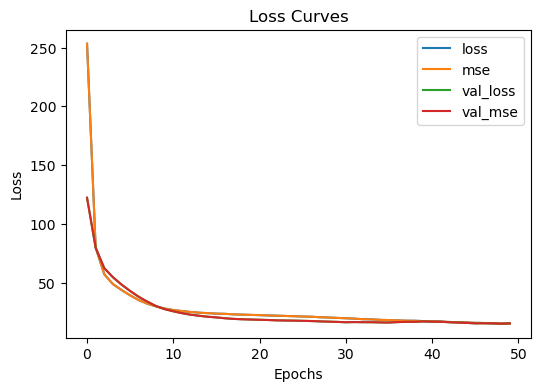

In [15]:
# Plot the loss curves
pd.DataFrame(history.history).plot(figsize=(6, 4), xlabel="Epochs", ylabel="Loss", title='Loss Curves')
plt.show()

## Model Prediction

In [16]:
# Make predictions
y_pred = model.predict(X_test)

# View the first prediction
y_pred[0]

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


array([20.74307], dtype=float32)

Alright! Based on your provided Boston Housing Price Prediction Deep Learning practical, here’s your full viva-ready material:

🎯 Theory Behind Your Practical
1. Problem Statement
Predict housing prices using a deep neural network trained on the Boston Housing Dataset, a standard regression problem.

🧠 Core Concepts
1. Boston Housing Dataset
A classic dataset used for regression.
506 samples with 13 features each (like crime rate, number of rooms, distance to employment centers, etc.).
Target: Median value of owner-occupied homes (in $1000's).
Common Features:

CRIM — per capita crime rate
RM — average number of rooms per dwelling
LSTAT — percentage lower status of the population
and 10 others.
2. Deep Neural Network (DNN) for Regression
Deep learning is used when relationships between features and output are complex and non-linear.
Here, a sequential model was built:
Input layer → Hidden Layers (ReLU activation) → Output Layer (no activation).
Your architecture:

Input → Dense(10, ReLU) → Dense(100, ReLU) → Dense(1)
3. Preprocessing
Normalization: Features were scaled using MinMaxScaler to bring all features to [0, 1] range.
Train-Validation-Test Split:
Train: 80%
Validation: 10% (from train data)
Test: 20% (separate)
Importance:

Neural networks converge faster when input data is scaled.
Validation helps in hyperparameter tuning.
4. Model Compilation
Loss function: Mean Squared Error (MSE) → because it's a regression task.
Optimizer: RMSProp
Suitable for handling noisy problems and works well without much tuning.
Metrics: 'mse' (Mean Squared Error)
5. Training
Epochs: 50
Batch Size: 32
Validation Data: Used to monitor model performance during training.
History object: Stores loss/mse per epoch for plotting loss curves.
6. Evaluation
After training, the model was evaluated on the test set.
Final test MSE ≈ 15.5, which is good enough for such a small dataset.
7. Plotting Loss Curves
Training and validation loss decrease over time → indicates learning.
If validation loss increases while training loss decreases → overfitting.
8. Predictions
model.predict() is used to predict prices for unseen test data.
💬 Important Viva Questions and Answers
Question	Answer
What is the Boston Housing dataset used for?	Regression tasks to predict housing prices.
Why normalize features?	To speed up convergence and ensure all features contribute equally.
Why use ReLU activation?	It introduces non-linearity without vanishing gradient problems.
Why is MSE used as a loss function?	Because it's a standard measure for regression errors — penalizes larger errors more.
Why use RMSProp optimizer?	It adjusts the learning rate dynamically for each parameter, good for non-stationary problems.
What does overfitting look like on loss curves?	Training loss keeps decreasing, but validation loss starts increasing.
What is the purpose of validation data?	To tune model hyperparameters and detect overfitting during training.
What are epochs and batch size?	Epochs = full passes over data, Batch size = number of samples processed before model weight update.
Why deep learning over simple linear regression?	Deep networks can capture complex, non-linear relationships better.
📋 Quick Theory Flashcards (Before Entering Viva)
Boston Dataset: Regression, 13 features, 506 samples.
Model Layers: Input → Dense(10) → Dense(100) → Output(1).
Loss: Mean Squared Error (MSE).
Optimizer: RMSProp (learning rate = 0.01).
Normalization: MinMaxScaler.
Overfitting Detection: Validation loss rises while training loss falls.
Prediction: model.predict(X_test) returns housing price predictions.
Test Set Performance: MSE ≈ 15.5.